### Import Data

In [1]:
import polars as pl
from great_tables import GT
import math

events = pl.read_csv(
    "data/2025-10-11.Team.A.@.Team.D.Events.csv",
    schema_overrides={"Player_Id": pl.String},
)

shifts = pl.read_csv("data/2025-10-11.Team.A.@.Team.D.Shifts.csv")

tracking_p1 = pl.read_csv(
    "data/2025-10-11.Team.A.@.Team.D.Tracking_P1.csv",
    schema_overrides={"Rink Location Z (Feet)": pl.Float64},
).drop("Player Id")

tracking_p2 = pl.read_csv(
    "data/2025-10-11.Team.A.@.Team.D.Tracking_P2.csv",
    schema_overrides={"Rink Location Z (Feet)": pl.Float64},
).drop("Player Id")

tracking_p3 = pl.read_csv(
    "data/2025-10-11.Team.A.@.Team.D.Tracking_P3.csv",
    schema_overrides={"Rink Location Z (Feet)": pl.Float64},
).drop("Player Id")


# Convert clock strings ("MM:SS" / "M:SS") to total seconds.
# events.Clock uses zero-padded minutes ("09:30"); tracking "Game Clock" is unpadded ("9:30").
# Casting both to integer seconds makes them directly comparable for joins.
def clock_to_seconds(col):
    parts = pl.col(col).str.split(":")
    return (
        parts.list.get(0).cast(pl.Int64) * 60
        + parts.list.get(1).cast(pl.Int64)
    )


# Add the seconds column and slot it right after its source column.
def add_seconds_after(df, src, new):
    df = df.with_columns(clock_to_seconds(src).alias(new))
    cols = [c for c in df.columns if c != new]
    cols.insert(df.get_column_index(src) + 1, new)
    return df.select(cols)


events = add_seconds_after(events, "Clock", "Clock_Seconds")

tracking_p1 = add_seconds_after(tracking_p1, "Game Clock", "Game_Clock_Seconds")
tracking_p2 = add_seconds_after(tracking_p2, "Game Clock", "Game_Clock_Seconds")
tracking_p3 = add_seconds_after(tracking_p3, "Game Clock", "Game_Clock_Seconds")

### Distribution of Shot Types in the dataset

In [2]:
shot_types = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .group_by("Detail_1")
    .agg(pl.len().alias("count"))
    .with_columns((pl.col("count") / pl.col("count").sum()).alias("pct"))
    .sort("count", descending=True)
)

(
    GT(shot_types)
    .tab_header(title="Distribution of shot types in the dataset")
    .cols_label(Detail_1="Shot Type", pct="% of Shots")
    .fmt_percent("pct", decimals=1)
    .cols_hide("count")
    .cols_width({"Detail_1": "150px", "pct": "110px"})
)


GT(_tbl_data=shape: (6, 3)
┌─────────────┬───────┬──────────┐
│ Detail_1    ┆ count ┆ pct      │
│ ---         ┆ ---   ┆ ---      │
│ str         ┆ u32   ┆ f64      │
╞═════════════╪═══════╪══════════╡
│ Wristshot   ┆ 70    ┆ 0.588235 │
│ Snapshot    ┆ 26    ┆ 0.218487 │
│ Deflection  ┆ 11    ┆ 0.092437 │
│ Slapshot    ┆ 6     ┆ 0.05042  │
│ Fan         ┆ 5     ┆ 0.042017 │
│ Wrap Around ┆ 1     ┆ 0.008403 │
└─────────────┴───────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x10dca6cf0>, _boxhead=Boxhead([ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='150px'), ColInfo(var='count', type=<ColInfoTypeEnum.hidden: 4>, column_label='count', column_align='right', column_width=None), ColInfo(var='pct', type=<ColInfoTypeEnum.default: 1>, column_label='% of Shots', column_align='right', column_width='110px')]), _stub=<great_tables._gt_data.Stub object at 0x10dca6a50>, _spanners=Spanners([]), _heading=Heading(title='Distribution of shot types in the dataset', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x10dca70e0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x10de1ac10>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x10dca7230>, _formats=[<great_tables._gt_data.FormatInfo object at 0x10dca6f90>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_bord

### Distribution of Shot Outcomes in the dataset

In [3]:
events.filter(pl.col("Event").is_in(["Shot", "Goal"])).select(
    "Event", "Detail_1", "Detail_2", "Detail_3", "Detail_4"
)

Event,Detail_1,Detail_2,Detail_3,Detail_4
str,str,str,i64,i64
"""Shot""","""Wristshot""","""Blocked""",1,0
"""Shot""","""Wristshot""","""Blocked""",0,0
"""Shot""","""Wristshot""","""Missed""",1,0
"""Shot""","""Deflection""","""On Net""",1,0
"""Shot""","""Wristshot""","""On Net""",0,0
…,…,…,…,…
"""Shot""","""Snapshot""","""On Net""",0,0
"""Shot""","""Snapshot""","""On Net""",0,0
"""Shot""","""Slapshot""","""On Net""",1,1


In [4]:
events.filter(pl.col("Event").is_in(["Shot", "Goal"])).get_column(
    "Detail_2"
).unique().sort()

Detail_2
str
"""Blocked"""
"""Missed"""
"""On Net"""


In [5]:
descriptions = {
    "Saved": "The shot is on target and saved by the goaltender.",
    "Goal": "The shot is on target and not saved by the goaltender, resulting in a goal.",
    "Blocked": "The shot is blocked by a skater from the defending team.",
    "Missed": "The shot is not on target.",
}

shot_outcomes = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .with_columns(
        pl.when(pl.col("Event") == "Goal")
        .then(pl.lit("Goal"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "On Net"))
        .then(pl.lit("Saved"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Blocked"))
        .then(pl.lit("Blocked"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Missed"))
        .then(pl.lit("Missed"))
        .alias("Outcome")
    )
    .group_by("Outcome")
    .agg(pl.len().alias("count"))
    .with_columns((pl.col("count") / pl.col("count").sum()).alias("pct"))
    .with_columns(pl.col("Outcome").replace(descriptions).alias("Description"))
    .select("Outcome", "Description", "pct")
    .sort("pct", descending=True)
)

(
    GT(shot_outcomes)
    .tab_header(title="Distribution of shot outcomes in the dataset")
    .cols_label(
        Outcome="Shot Outcome",
        Description="Description",
        pct="% of Shots",
    )
    .fmt_percent("pct", decimals=1)
    .cols_width({"Outcome": "130px", "Description": "420px", "pct": "110px"})
)


GT(_tbl_data=shape: (4, 3)
┌─────────┬─────────────────────────────────┬──────────┐
│ Outcome ┆ Description                     ┆ pct      │
│ ---     ┆ ---                             ┆ ---      │
│ str     ┆ str                             ┆ f64      │
╞═════════╪═════════════════════════════════╪══════════╡
│ Saved   ┆ The shot is on target and save… ┆ 0.470588 │
│ Missed  ┆ The shot is not on target.      ┆ 0.260504 │
│ Blocked ┆ The shot is blocked by a skate… ┆ 0.218487 │
│ Goal    ┆ The shot is on target and not … ┆ 0.05042  │
└─────────┴─────────────────────────────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x10deab5c0>, _boxhead=Boxhead([ColInfo(var='Outcome', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Outcome', column_align='left', column_width='130px'), ColInfo(var='Description', type=<ColInfoTypeEnum.default: 1>, column_label='Description', column_align='left', column_width='420px'), ColInfo(var='pct', type=<ColInfoTypeEnum.default: 1>, column_label='% of Shots', column_align='right', column_width='110px')]), _stub=<great_tables._gt_data.Stub object at 0x10de1a850>, _spanners=Spanners([]), _heading=Heading(title='Distribution of shot outcomes in the dataset', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x10de1afd0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x10deab360>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x10de1bc50>, _formats=[<great_tables._gt_data.FormatInfo object at 0x10de1bd90>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=Options

### Feature-Based Expected Goals Model

#### Visualize Shot Location

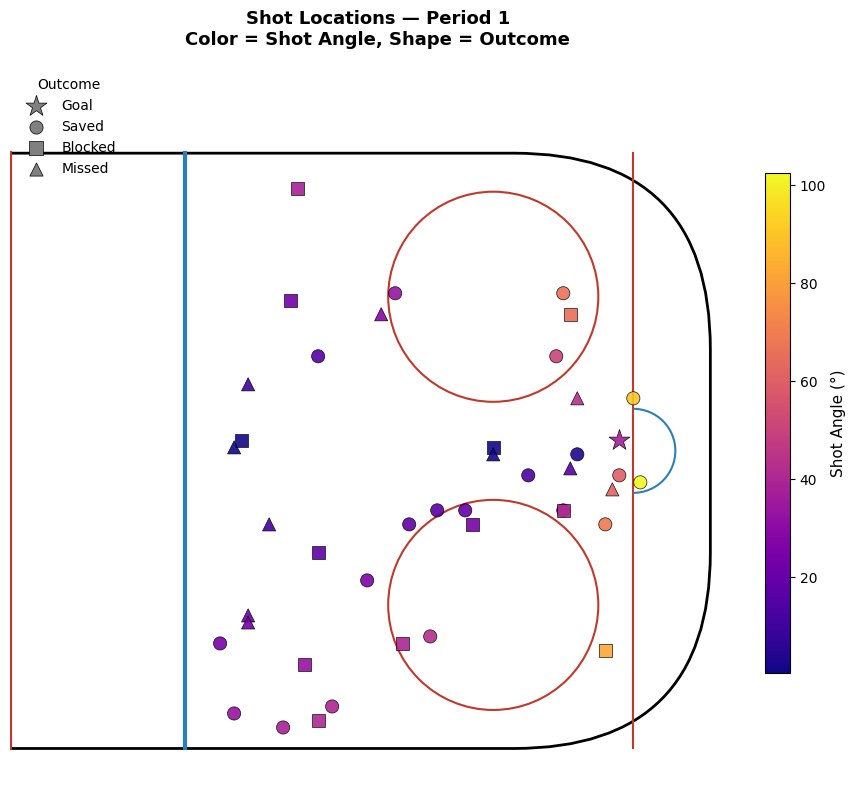

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Arc, Circle, FancyBboxPatch

# Prepare shot data with outcome labels, normalized coordinates, and shot angle
shot_data = (
    events
    .filter(
        pl.col("Event").is_in(["Shot", "Goal"]),
        pl.col("Period") == 1,
    )
    .with_columns(
        pl.when(pl.col("Event") == "Goal")
        .then(pl.lit("Goal"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "On Net"))
        .then(pl.lit("Saved"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Blocked"))
        .then(pl.lit("Blocked"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Missed"))
        .then(pl.lit("Missed"))
        .alias("Outcome")
    )
    # Normalize all shots to the right side
    .with_columns(
        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("X_Coordinate"))
        .otherwise(pl.col("X_Coordinate"))
        .alias("X_Coordinate"),

        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("Y_Coordinate"))
        .otherwise(pl.col("Y_Coordinate"))
        .alias("Y_Coordinate"),
    )
    # Compute shot angle: 0° = straight on, 90° = side of net
    .with_columns(
        (
            pl.arctan2(pl.col("Y_Coordinate"), 89 - pl.col("X_Coordinate"))
            .abs()
            * (180 / 3.141592653589793)
        ).alias("Shot_Angle")
    )
    .select("X_Coordinate", "Y_Coordinate", "Outcome", "Shot_Angle")
)

outcome_markers = {
    "Goal":    {"marker": "*", "size": 250},
    "Saved":   {"marker": "o", "size":  90},
    "Blocked": {"marker": "s", "size":  90},
    "Missed":  {"marker": "^", "size":  90},
}

cmap = plt.cm.plasma
angles = shot_data.get_column("Shot_Angle").to_list()
norm = mcolors.Normalize(vmin=min(angles), vmax=max(angles))

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#e8f4fb")

# --- Rink ---
ax.add_patch(FancyBboxPatch(
    (-100, -42.5), 200, 85,
    boxstyle="round,pad=0,rounding_size=28",
    linewidth=2, edgecolor="black", facecolor="white", zorder=1,
))
for x, color, lw in [(0, "#c0392b", 3.0), (25, "#2980b9", 3.0), (89, "#c0392b", 1.5)]:
    ax.plot([x, x], [-42.5, 42.5], color=color, linewidth=lw, zorder=2)
for y in [22, -22]:
    ax.add_patch(Circle((69, y), 15, fill=False, color="#c0392b", linewidth=1.5, zorder=2))
ax.add_patch(Arc((89, 0), 12, 12, theta1=270, theta2=90, color="#2980b9", linewidth=1.5, zorder=2))

# --- Plot shots: color = angle, shape = outcome ---
for outcome, style in outcome_markers.items():
    subset = shot_data.filter(pl.col("Outcome") == outcome)
    ax.scatter(
        subset.get_column("X_Coordinate").to_list(),
        subset.get_column("Y_Coordinate").to_list(),
        c=subset.get_column("Shot_Angle").to_list(),
        cmap=cmap, norm=norm,
        marker=style["marker"], s=style["size"],
        zorder=5, edgecolors="black", linewidths=0.5, alpha=0.9,
    )

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Shot Angle (°)", fontsize=11)

# --- Legend for shapes ---
handles = [
    plt.scatter([], [], marker=s["marker"], s=s["size"], c="gray",
                edgecolors="black", linewidths=0.5, label=o)
    for o, s in outcome_markers.items()
]
ax.legend(handles=handles, loc="upper left", fontsize=10, frameon=False, title="Outcome")

ax.set_xlim(0, 105)
ax.set_ylim(-47, 55)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Shot Locations — Period 1\nColor = Shot Angle, Shape = Outcome", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


#### Shot Location

In [7]:
shot_data.with_columns(
    (
        pl.arctan2(pl.col("Y_Coordinate"), pl.col("X_Coordinate") - 89)
        .abs()
        * (180 / 3.141592653589793)
    ).alias("Shot_Angle")
)

X_Coordinate,Y_Coordinate,Outcome,Shot_Angle
f64,f64,str,f64
42.0,-30.5,"""Blocked""",147.019002
79.0,-8.5,"""Blocked""",139.635463
34.0,-23.5,"""Missed""",156.864303
74.0,-3.5,"""Saved""",166.865978
81.0,-0.5,"""Saved""",176.423666
…,…,…,…
86.0,-5.5,"""Missed""",118.61046
90.0,-4.5,"""Saved""",77.471192
87.0,1.5,"""Goal""",143.130102


In [8]:

(
    events
    .filter(pl.col("Event").is_in(["Shot", "Goal"]))
    # Normalize to right side
    .with_columns(
        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("X_Coordinate"))
        .otherwise(pl.col("X_Coordinate"))
        .alias("X_Coordinate"),

        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("Y_Coordinate"))
        .otherwise(pl.col("Y_Coordinate"))
        .alias("Y_Coordinate"),
    )
    # Shot angle (degrees) and meridian distance
    .with_columns(
        (
            pl.arctan2(pl.col("Y_Coordinate"), 89 - pl.col("X_Coordinate"))
            .abs()
            * (180 / math.pi)
        ).alias("Shot_Angle"),
        pl.col("Y_Coordinate").abs().alias("d_m"),
    )
    # Distance via trigonometry: d = d_m / sin(θ), fallback to (89 - x) when Y = 0
    .with_columns(
        pl.when(pl.col("d_m") == 0)
        .then(89 - pl.col("X_Coordinate"))
        .otherwise(
            pl.col("d_m") / (pl.col("Shot_Angle") * math.pi / 180).sin()
        )
        .alias("d_trig"),
        # Euclidean distance as sanity check
        ((89 - pl.col("X_Coordinate")).pow(2) + pl.col("Y_Coordinate").pow(2))
        .sqrt()
        .alias("d_euclidean"),
    )
    .select("X_Coordinate", "Y_Coordinate", "Shot_Angle", "d_m", "d_trig", "d_euclidean")
)

X_Coordinate,Y_Coordinate,Shot_Angle,d_m,d_trig,d_euclidean
f64,f64,f64,f64,f64,f64
42.0,-30.5,32.980998,30.5,56.02901,56.02901
79.0,-8.5,40.364537,8.5,13.124405,13.124405
34.0,-23.5,23.135697,23.5,59.810116,59.810116
74.0,-3.5,13.134022,3.5,15.402922,15.402922
81.0,-0.5,3.576334,0.5,8.01561,8.01561
…,…,…,…,…,…
88.0,5.5,79.695154,5.5,5.59017,5.59017
86.0,-9.5,72.474432,9.5,9.962429,9.962429
52.0,-22.5,31.304123,22.5,43.304157,43.304157


Find distance measures and shot angle, specified in 2.4.1.1 Shot Location

#### Shooter Motion

In [9]:
# Goal: the shooter's *speed* (magnitude of velocity) at the instant they shot.
# Tracking gives position over time; events tell us who/when/where each shot was.
#
# Tracking runs at ~30 fps: the "Image Id" suffix is a per-period frame counter that
# ticks ~30 times per game-clock second (e.g. "..._066486" -> "..._066487"). Frames
# occasionally drop, so velocity uses the *actual* frame-index gap for dt, never an
# assumed constant. We smooth with a small central difference to damp tracking jitter.

FPS = 30                  # tracking frame rate (frames per second)
SMOOTH_K = 3              # central-difference half-window (~0.1 s each side)
FT_PER_S_TO_MPH = 0.6818  # 1 ft/s = 0.6818 mph
MAX_SPEED_MPH = 30.0      # human skaters peak ~25 mph; above this is a tracking glitch
MAX_SPEED_FPS = MAX_SPEED_MPH / FT_PER_S_TO_MPH

# One table of every tracked player-frame across the three periods.
tracking = pl.concat([tracking_p1, tracking_p2, tracking_p3])

players = (
    tracking
    .filter(pl.col("Player or Puck") == "Player")
    .with_columns(
        # Numeric frame index from the Image Id suffix, and jersey as a string for matching.
        pl.col("Image Id").str.split("_").list.last().cast(pl.Int64).alias("Frame"),
        pl.col("Player Jersey Number").cast(pl.String).alias("Jersey"),
    )
    # Drop rows whose jersey couldn't be read: they'd all collapse into one bogus "null"
    # track, and differencing positions of *different* players invents huge fake speeds.
    .filter(pl.col("Jersey").is_not_null())
    # Order each player's frames in time so shift() walks consecutive samples.
    .sort(["Period", "Team", "Jersey", "Frame"])
    .with_columns(
        # Central difference over +/- SMOOTH_K frames, partitioned per player-period.
        (pl.col("Rink Location X (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location X (Feet)").shift(SMOOTH_K))
            .over(["Period", "Team", "Jersey"]).alias("dx"),
        (pl.col("Rink Location Y (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location Y (Feet)").shift(SMOOTH_K))
            .over(["Period", "Team", "Jersey"]).alias("dy"),
        (pl.col("Frame").shift(-SMOOTH_K) - pl.col("Frame").shift(SMOOTH_K))
            .over(["Period", "Team", "Jersey"]).alias("dframe"),
    )
    .with_columns(
        # dt = frames / fps (seconds); speed = displacement / dt, in feet per second.
        ((pl.col("dx") ** 2 + pl.col("dy") ** 2).sqrt() / (pl.col("dframe") / FPS)).alias("speed_fps")
    )
    .with_columns(
        # Null out physically impossible speeds (tracking ID-swaps / position jumps) so
        # they don't poison the per-shot pick or its fallback median.
        pl.when(pl.col("speed_fps") <= MAX_SPEED_FPS).then(pl.col("speed_fps")).otherwise(None).alias("speed_fps")
    )
    .with_columns(
        (pl.col("speed_fps") * FT_PER_S_TO_MPH).alias("speed_mph")
    )
)

players.select(
    "Period", "Team", "Jersey", "Frame", "Game_Clock_Seconds",
    "Rink Location X (Feet)", "Rink Location Y (Feet)", "speed_fps", "speed_mph",
)


Period,Team,Jersey,Frame,Game_Clock_Seconds,Rink Location X (Feet),Rink Location Y (Feet),speed_fps,speed_mph
i64,str,str,i64,i64,f64,f64,f64,f64
1,"""Away""","""14""",71948,1053,67.427,21.172,null,null
1,"""Away""","""14""",71949,1052,67.304,21.257,null,null
1,"""Away""","""14""",71950,1052,67.365,21.779,null,null
1,"""Away""","""14""",71951,1052,67.723,22.361,14.579383,9.940223
1,"""Away""","""14""",71952,1052,67.885,22.909,17.321562,11.809841
…,…,…,…,…,…,…,…,…
3,"""Home""","""Go""",325726,21,85.497,-1.456,9.326003,6.358469
3,"""Home""","""Go""",325727,21,85.204,-2.158,0.517046,0.352522
3,"""Home""","""Go""",325728,21,84.913,-2.747,null,null


In [10]:
# Match each Shot/Goal event to the tracking frame where the puck was released, then
# read the shooter's speed there.
#
# Matching keys: events Player_Id is a jersey number, but jerseys repeat across teams,
# so we match on Period + Team + Jersey. Event "Team" is a name (e.g. "Team A");
# tracking "Team" is Home/Away -> map via Home_Team/Away_Team.
#
# Pinning the release: the event stores the release X/Y. Within +/-1 game-clock second
# of the event we pick the shooter frame whose tracked position is closest to that
# release point. Event and tracking share the same rink frame here, but to be safe we
# also test the sign-flipped coords (-X,-Y) and keep whichever is closer.

shots = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .with_columns(
        pl.when(pl.col("Team") == pl.col("Home_Team")).then(pl.lit("Home"))
          .otherwise(pl.lit("Away")).alias("Track_Team")
    )
    .with_row_index("shot_id")
)

# Candidate shooter frames: same player, within the event second (+/-1s), valid position.
cand = (
    shots.join(
        players.select([
            "Period", "Team", "Jersey", "Game_Clock_Seconds", "Frame",
            "Rink Location X (Feet)", "Rink Location Y (Feet)", "speed_fps",
        ]),
        left_on=["Period", "Track_Team", "Player_Id"],
        right_on=["Period", "Team", "Jersey"], how="left",
    )
    .filter((pl.col("Game_Clock_Seconds") - pl.col("Clock_Seconds")).abs() <= 1)
    .filter(pl.col("Rink Location X (Feet)").is_not_null()
            & pl.col("Rink Location Y (Feet)").is_not_null())
    .with_columns(
        ((pl.col("Rink Location X (Feet)") - pl.col("X_Coordinate")) ** 2
         + (pl.col("Rink Location Y (Feet)") - pl.col("Y_Coordinate")) ** 2).sqrt().alias("d_direct"),
        ((pl.col("Rink Location X (Feet)") + pl.col("X_Coordinate")) ** 2
         + (pl.col("Rink Location Y (Feet)") + pl.col("Y_Coordinate")) ** 2).sqrt().alias("d_flip"),
    )
    .with_columns(
        pl.min_horizontal("d_direct", "d_flip").alias("match_dist"),
        (pl.col("d_flip") < pl.col("d_direct")).alias("used_flip"),
    )
)

# Release frame = the candidate closest to the release point (nulls_last so a real
# match is never beaten by a missing distance).
release = (
    cand.sort("match_dist", nulls_last=True)
    .group_by("shot_id", maintain_order=True)
    .first()
    .select(["shot_id", "Frame", "match_dist", "used_flip", "speed_fps"])
)

# Fallback: representative speed over the whole event-second window.
window_med = cand.group_by("shot_id").agg(
    pl.col("speed_fps").median().alias("speed_fps_window_median"),
    pl.len().alias("n_candidates"),
)

# A match is trusted when the closest frame is within ~10 ft and has a defined speed;
# otherwise fall back to the window median (flagged), or mark no tracking at all.
MAX_MATCH_DIST = 10.0
shot_speeds = (
    shots.join(release, on="shot_id", how="left")
    .join(window_med, on="shot_id", how="left")
    .with_columns(
        pl.when((pl.col("match_dist") <= MAX_MATCH_DIST) & pl.col("speed_fps").is_not_null())
          .then(pl.col("speed_fps"))
          .otherwise(pl.col("speed_fps_window_median"))
          .alias("shooter_speed_fps"),
        pl.when((pl.col("match_dist") <= MAX_MATCH_DIST) & pl.col("speed_fps").is_not_null())
          .then(pl.lit("matched"))
          .when(pl.col("speed_fps_window_median").is_not_null())
          .then(pl.lit("fallback_window_median"))
          .otherwise(pl.lit("no_tracking"))
          .alias("match_quality"),
    )
    .with_columns((pl.col("shooter_speed_fps") * 0.6818).alias("shooter_speed_mph"))
    .sort(["Period", "Clock_Seconds"], descending=[False, True])
)

print(shot_speeds["match_quality"].value_counts())
shot_speeds.select(
    "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
    "Frame", "match_dist", "used_flip", "shooter_speed_fps", "shooter_speed_mph", "match_quality",
).head()


shape: (2, 2)
┌────────────────────────┬───────┐
│ match_quality          ┆ count │
│ ---                    ┆ ---   │
│ str                    ┆ u32   │
╞════════════════════════╪═══════╡
│ fallback_window_median ┆ 2     │
│ matched                ┆ 117   │
└────────────────────────┴───────┘


Period,Clock,Team,Player_Id,Event,Detail_1,Frame,match_dist,used_flip,shooter_speed_fps,shooter_speed_mph,match_quality
i64,str,str,str,str,str,i64,f64,bool,f64,f64,str
1,"""19:54""","""Team D""","""42""","""Shot""","""Wristshot""",65668,1.257159,false,22.062466,15.04219,"""matched"""
1,"""19:26""","""Team A""","""29""","""Shot""","""Wristshot""",66490,3.945989,false,20.065956,13.680969,"""matched"""
1,"""19:16""","""Team A""","""72""","""Shot""","""Wristshot""",66824,4.759513,false,4.372238,2.980992,"""matched"""
1,"""19:15""","""Team A""","""29""","""Shot""","""Deflection""",66861,1.051468,false,3.771091,2.57113,"""matched"""
1,"""19:13""","""Team A""","""63""","""Shot""","""Wristshot""",66873,0.13366,false,4.189063,2.856103,"""matched"""


In [11]:
# Shooter speed at the moment of each shot, in ft/s and mph.
shot_speed_table = shot_speeds.select(
    "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
    "shooter_speed_fps", "shooter_speed_mph", "match_quality",
)

(
    GT(shot_speed_table)
    .tab_header(
        title="Shooter speed at the moment of the shot",
        subtitle="Magnitude of the shooter's velocity from tracking, pinned to the release frame",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        shooter_speed_fps="Speed (ft/s)",
        shooter_speed_mph="Speed (mph)",
        match_quality="Match",
    )
    .fmt_number(["shooter_speed_fps", "shooter_speed_mph"], decimals=1)
    .cols_width({
        "Period": "70px", "Clock": "70px", "Team": "90px", "Player_Id": "70px",
        "Event": "70px", "Detail_1": "110px",
        "shooter_speed_fps": "110px", "shooter_speed_mph": "110px", "match_quality": "150px",
    })
)


GT(_tbl_data=shape: (119, 9)
┌────────┬───────┬────────┬───────────┬───┬────────────┬──────────────┬──────────────┬─────────────┐
│ Period ┆ Clock ┆ Team   ┆ Player_Id ┆ … ┆ Detail_1   ┆ shooter_spee ┆ shooter_spee ┆ match_quali │
│ ---    ┆ ---   ┆ ---    ┆ ---       ┆   ┆ ---        ┆ d_fps        ┆ d_mph        ┆ ty          │
│ i64    ┆ str   ┆ str    ┆ str       ┆   ┆ str        ┆ ---          ┆ ---          ┆ ---         │
│        ┆       ┆        ┆           ┆   ┆            ┆ f64          ┆ f64          ┆ str         │
╞════════╪═══════╪════════╪═══════════╪═══╪════════════╪══════════════╪══════════════╪═════════════╡
│ 1      ┆ 19:54 ┆ Team D ┆ 42        ┆ … ┆ Wristshot  ┆ 22.062466    ┆ 15.04219     ┆ matched     │
│ 1      ┆ 19:26 ┆ Team A ┆ 29        ┆ … ┆ Wristshot  ┆ 20.065956    ┆ 13.680969    ┆ matched     │
│ 1      ┆ 19:16 ┆ Team A ┆ 72        ┆ … ┆ Wristshot  ┆ 4.372238     ┆ 2.980992     ┆ matched     │
│ 1      ┆ 19:15 ┆ Team A ┆ 29        ┆ … ┆ Deflection ┆ 3.771091     ┆ 2.57113      ┆ matched     │
│ 1      ┆ 19:13 ┆ Team A ┆ 63        ┆ … ┆ Wristshot  ┆ 4.189063     ┆ 2.856103     ┆ matched     │
│ …      ┆ …     ┆ …      ┆ …         ┆ … ┆ …          ┆ …            ┆ …            ┆ …           │
│ 3      ┆ 03:48 ┆ Team D ┆ 8         ┆ … ┆ Snapshot   ┆ 15.033696    ┆ 10.249974    ┆ matched     │
│ 3      ┆ 03:47 ┆ Team D ┆ 25        ┆ … ┆ Snapshot   ┆ 7.157486     ┆ 4.879974     ┆ matched     │
│ 3      ┆ 03:18 ┆ Team D ┆ 51        ┆ … ┆ Slapshot   ┆ 0.979247     ┆ 0.667651     ┆ matched     │
│ 3      ┆ 01:14 ┆ Team D ┆ 36        ┆ … ┆ Wristshot  ┆ 1.001299     ┆ 0.682686     ┆ matched     │
│ 3      ┆ 01:09 ┆ Team D ┆ 25        ┆ … ┆ Snapshot   ┆ 5.715306     ┆ 3.896696     ┆ matched     │
└────────┴───────┴────────┴───────────┴───┴────────────┴──────────────┴──────────────┴─────────────┘, _body=<great_tables._gt_data.Body object at 0x12e3c7570>, _boxhead=Boxhead([ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='70px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='70px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='90px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Jersey', column_align='left', column_width='70px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='70px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='110px'), ColInfo(var='shooter_speed_fps', type=<ColInfoTypeEnum.default: 1>, column_label='Speed (ft/s)', column_align='right', column_width='110px'), ColInfo(var='shooter_speed_mph', type=<ColInfoTypeEnum.default: 1>, column_label='Speed (mph)', column_align='right', column_width='110px'), ColInfo(var='match_quality', type=<ColInfoTypeEnum.default: 1>, column_label='Match', column_align='left', column_width='150px')]), _stub=<great_tables._gt_data.Stub object at 0x12e526d50>, _spanners=Spanners([]), _heading=Heading(title='Shooter speed at the moment of the shot', subtitle="Magnitude of the shooter's velocity from tracking, pinned to the release frame", preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x12e377a80>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x12e413650>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x12e5682d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x12e568690>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=

#### Pressure

In [12]:
# Pressure: distance from the shot location to the closest and second-closest
# *defending skater*. Following the cited paper, a continuous distance is more
# descriptive than counting defenders within 6 ft, and adding the second-closest
# defender captures pressure from multiple defenders.
#
# Goalies (jersey "Go") are excluded: a goalie sits in the crease on nearly every
# shot, so it would dominate the "closest defender" distance without reflecting
# real defensive pressure.
#
# We reuse the release Frame matched in the shooter-speed step: at that frame we take
# every opposing skater's tracked position and measure straight-line distance to the
# shot location. "used_flip" (from the same matching) tells us whether the event's
# (X, Y) had to be negated to line up with the tracking frame for that shot, so we
# apply the same flip to the shot coordinates here.
#
# Note: tracking coverage is partial -- many frames carry fewer than 5 skaters per team
# (see n_defenders). Coverage concentrates near the play, so the closest defenders (the
# ones this feature needs) are the most reliably tracked; n_defenders records how many
# defenders were actually visible at each shot's release frame.

# Defending skaters only: opposite tracking team, real jersey numbers, no goalies.
defenders = (
    players
    .filter(pl.col("Jersey") != "Go")
    .select([
        "Period", "Team", "Frame",
        "Rink Location X (Feet)", "Rink Location Y (Feet)",
    ])
)

# Per shot: the defending team, the release frame, and the shot location in tracking
# coordinates (negated when the release match used the flip).
shot_frames = (
    shots
    .join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        pl.when(pl.col("Track_Team") == "Home").then(pl.lit("Away"))
          .otherwise(pl.lit("Home")).alias("Def_Team"),
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate"))
          .otherwise(pl.col("X_Coordinate")).alias("Shot_X"),
        pl.when(pl.col("used_flip")).then(-pl.col("Y_Coordinate"))
          .otherwise(pl.col("Y_Coordinate")).alias("Shot_Y"),
    )
    .select(["shot_id", "Period", "Def_Team", "Frame", "Shot_X", "Shot_Y"])
)

# Join each shot to every defending skater in its release frame; measure distance.
pressure = (
    shot_frames
    .join(
        defenders,
        left_on=["Period", "Def_Team", "Frame"],
        right_on=["Period", "Team", "Frame"],
        how="left",
    )
    .with_columns(
        ((pl.col("Rink Location X (Feet)") - pl.col("Shot_X")) ** 2
         + (pl.col("Rink Location Y (Feet)") - pl.col("Shot_Y")) ** 2)
        .sqrt().alias("def_dist")
    )
    .group_by("shot_id", maintain_order=True)
    .agg(
        pl.col("def_dist").sort(nulls_last=True).alias("def_dists"),
        pl.col("def_dist").is_not_null().sum().alias("n_defenders"),
    )
    .with_columns(
        pl.col("def_dists").list.get(0, null_on_oob=True).alias("closest_def_dist"),
        pl.col("def_dists").list.get(1, null_on_oob=True).alias("second_closest_def_dist"),
    )
    .drop("def_dists")
)

# Attach to the shots table for use as expected-goals model features.
shot_pressure = shots.join(pressure, on="shot_id", how="left").select(
    "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
    "n_defenders", "closest_def_dist", "second_closest_def_dist",
)


shot_pressure

Period,Clock,Team,Player_Id,Event,Detail_1,n_defenders,closest_def_dist,second_closest_def_dist
i64,str,str,str,str,str,u32,f64,f64
1,"""19:54""","""Team D""","""42""","""Shot""","""Wristshot""",5,6.790402,7.523492
1,"""19:26""","""Team A""","""29""","""Shot""","""Wristshot""",5,5.278327,5.753678
1,"""19:16""","""Team A""","""72""","""Shot""","""Wristshot""",5,15.109349,29.14028
1,"""19:15""","""Team A""","""29""","""Shot""","""Deflection""",5,5.497651,5.7115
1,"""19:13""","""Team A""","""63""","""Shot""","""Wristshot""",5,6.053296,9.416049
…,…,…,…,…,…,…,…,…
3,"""03:48""","""Team D""","""8""","""Shot""","""Snapshot""",5,5.698291,10.224393
3,"""03:47""","""Team D""","""25""","""Shot""","""Snapshot""",5,4.72361,16.373568
3,"""03:18""","""Team D""","""51""","""Shot""","""Slapshot""",5,9.675628,30.060177


Pre-Shot Movement

In [62]:
# Pre-shot movement features, focused on lateral puck movement (following the cited
# paper / Stathletes "Opportunity Analysis"):
#
#   1. time_since_meridian  -- seconds since the puck last crossed the meridian
#   2. meridian_cross_dist  -- where it crossed, as distance to the goal line
#   3. avg_puck_speed       -- average puck speed in the 1 s before the shot
#
# The "meridian" is the Y = 0 line running net-to-net down the center of the ice; the
# puck crosses it when its Y coordinate changes sign (lateral / east-west movement,
# which forces the goalie across and raises shot danger). Features 1 and 2 are only
# defined when the crossing happened within 5 s before the shot.
#
# We reuse the per-shot release Frame and "used_flip" orientation matched in the
# shooter-speed step. Puck X/Y are normalized to attack-right (net at +89) using each
# shot's orientation so the goal-line distance is signed consistently: a crossing in
# front of the net is positive, one behind the goal line (X > 89) is negative.

# The puck moves far faster than skaters, so the 30 mph skater cap doesn't apply; we
# only drop physically impossible jumps (tracking glitches) above ~110 mph.
MAX_PUCK_SPEED_MPH = 110.0
MAX_PUCK_SPEED_FPS = MAX_PUCK_SPEED_MPH / FT_PER_S_TO_MPH

# Clean puck track with per-frame speed (same central-difference scheme as players,
# but partitioned by Period only -- the puck is a single object). ~95% of puck rows
# carry a valid position; the rest are dropped.
puck = (
    tracking
    .filter(pl.col("Player or Puck") == "Puck")
    .filter(pl.col("Rink Location X (Feet)").is_not_null())
    .with_columns(
        pl.col("Image Id").str.split("_").list.last().cast(pl.Int64).alias("Frame")
    )
    .sort(["Period", "Frame"])
    .with_columns(
        (pl.col("Rink Location X (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location X (Feet)").shift(SMOOTH_K)).over("Period").alias("dx"),
        (pl.col("Rink Location Y (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location Y (Feet)").shift(SMOOTH_K)).over("Period").alias("dy"),
        (pl.col("Frame").shift(-SMOOTH_K) - pl.col("Frame").shift(SMOOTH_K)).over("Period").alias("dframe"),
    )
    .with_columns(
        ((pl.col("dx") ** 2 + pl.col("dy") ** 2).sqrt() / (pl.col("dframe") / FPS)).alias("puck_speed_fps")
    )
    .with_columns(
        pl.when(pl.col("puck_speed_fps") <= MAX_PUCK_SPEED_FPS).then(pl.col("puck_speed_fps")).otherwise(None).alias("puck_speed_fps")
    )
    .select(["Period", "Frame", "Rink Location X (Feet)", "Rink Location Y (Feet)", "puck_speed_fps"])
    .rename({"Rink Location X (Feet)": "puck_x", "Rink Location Y (Feet)": "puck_y"})
)

# Per-shot orientation: the shot location in tracking coords (negated when the release
# match used the flip) tells us which goal line the team attacks (+89 if X > 0).
shot_orient = (
    shots.join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate")).otherwise(pl.col("X_Coordinate")).alias("Shot_X_track")
    )
    .with_columns((pl.col("Shot_X_track") > 0).alias("attack_right"))
    .select(["shot_id", "Period", "Frame", "attack_right"])
    .rename({"Frame": "shot_frame"})
)

# Puck samples in the same period within 5 s (150 frames) before each shot, with
# coordinates normalized to attack-right. (The meridian sign-change is invariant to the
# flip; normalizing X only matters for the goal-line distance.)
window = (
    shot_orient.join(puck, on="Period", how="left")
    .filter((pl.col("shot_frame") - pl.col("Frame")).is_between(0, 5 * FPS))
    .with_columns(
        pl.when(pl.col("attack_right")).then(pl.col("puck_x")).otherwise(-pl.col("puck_x")).alias("px"),
        pl.when(pl.col("attack_right")).then(pl.col("puck_y")).otherwise(-pl.col("puck_y")).alias("py"),
    )
    .sort(["shot_id", "Frame"])
)

# Feature 3: average puck speed over the 1 s (30 frames) before the shot.
avg_speed = (
    window.filter((pl.col("shot_frame") - pl.col("Frame")).is_between(0, 1 * FPS))
    .group_by("shot_id")
    .agg(pl.col("puck_speed_fps").mean().alias("avg_puck_speed_fps"))
    .with_columns((pl.col("avg_puck_speed_fps") * FT_PER_S_TO_MPH).alias("avg_puck_speed_mph"))
)

# Features 1 & 2: the most recent meridian crossing within the 5 s window. A crossing is
# a sign change in py between consecutive frames; we linearly interpolate the X where
# py = 0, then keep the latest crossing (largest Frame) before the shot.
crossings = (
    window.with_columns(
        pl.col("px").shift(1).over("shot_id").alias("px_prev"),
        pl.col("py").shift(1).over("shot_id").alias("py_prev"),
    )
    .filter(pl.col("py_prev").is_not_null() & (pl.col("py_prev") * pl.col("py") < 0))
    .with_columns(
        (pl.col("px_prev") + (pl.col("px") - pl.col("px_prev")) * (0 - pl.col("py_prev")) / (pl.col("py") - pl.col("py_prev"))).alias("x_cross")
    )
    .sort(["shot_id", "Frame"])
    .group_by("shot_id", maintain_order=True)
    .last()
    .with_columns(
        ((pl.col("shot_frame") - pl.col("Frame")) / FPS).alias("time_since_meridian"),
        (89 - pl.col("x_cross")).alias("meridian_cross_dist"),  # negative if crossed behind the net
    )
    .select(["shot_id", "time_since_meridian", "meridian_cross_dist"])
)

# Attach to the shots table; nulls mark shots with no meridian crossing in the prior 5 s.
pre_shot_movement = (
    shots.join(crossings, on="shot_id", how="left")
    .join(avg_speed, on="shot_id", how="left")
    .sort(["Period", "Clock_Seconds"], descending=[False, True])
    .select(
        "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
        "time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps", "avg_puck_speed_mph",
    )
)

(
    GT(pre_shot_movement)
    .tab_header(
        title="Pre-shot puck movement",
        subtitle="Lateral movement (meridian crossings) and puck speed in the lead-up to each shot",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        time_since_meridian="Time Since Meridian (s)",
        meridian_cross_dist="Cross Dist to Goal Line (ft)",
        avg_puck_speed_fps="Puck Speed (ft/s)",
        avg_puck_speed_mph="Puck Speed (mph)",
    )
    .fmt_number(
        ["time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps", "avg_puck_speed_mph"],
        decimals=1,
    )
    .sub_missing(columns=["time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps", "avg_puck_speed_mph"], missing_text="—")
    .cols_width({
        "Period": "60px", "Clock": "60px", "Team": "80px", "Player_Id": "60px",
        "Event": "60px", "Detail_1": "100px",
        "time_since_meridian": "120px", "meridian_cross_dist": "130px",
        "avg_puck_speed_fps": "110px", "avg_puck_speed_mph": "110px",
    })
)


GT(_tbl_data=shape: (119, 10)
┌─────┬─────┬─────┬─────┬───┬─────┬────────┬───────┬───────┐
│ Per ┆ Clo ┆ Tea ┆ Pla ┆ … ┆ tim ┆ meridi ┆ avg_p ┆ avg_p │
│ iod ┆ ck  ┆ m   ┆ yer ┆   ┆ e_s ┆ an_cro ┆ uck_s ┆ uck_s │
│ --- ┆ --- ┆ --- ┆ _Id ┆   ┆ inc ┆ ss_dis ┆ peed_ ┆ peed_ │
│ i64 ┆ str ┆ str ┆ --- ┆   ┆ e_m ┆ t      ┆ fps   ┆ mph   │
│     ┆     ┆     ┆ str ┆   ┆ eri ┆ ---    ┆ ---   ┆ ---   │
│     ┆     ┆     ┆     ┆   ┆ dia ┆ f64    ┆ f64   ┆ f64   │
│     ┆     ┆     ┆     ┆   ┆ n   ┆        ┆       ┆       │
│     ┆     ┆     ┆     ┆   ┆ --- ┆        ┆       ┆       │
│     ┆     ┆     ┆     ┆   ┆ f64 ┆        ┆       ┆       │
╞═════╪═════╪═════╪═════╪═══╪═════╪════════╪═══════╪═══════╡
│ 1   ┆ 19: ┆ Tea ┆ 42  ┆ … ┆ nul ┆ null   ┆ 38.96 ┆ 26.56 │
│     ┆ 54  ┆ m D ┆     ┆   ┆ l   ┆        ┆ 9471  ┆ 9385  │
│ 1   ┆ 19: ┆ Tea ┆ 29  ┆ … ┆ nul ┆ null   ┆ 21.96 ┆ 14.97 │
│     ┆ 26  ┆ m A ┆     ┆   ┆ l   ┆        ┆ 4825  ┆ 5617  │
│ 1   ┆ 19: ┆ Tea ┆ 72  ┆ … ┆ nul ┆ null   ┆ null  ┆ null  │
│     ┆ 16  ┆ m A ┆     ┆   ┆ l   ┆        ┆       ┆       │
│ 1   ┆ 19: ┆ Tea ┆ 29  ┆ … ┆ nul ┆ null   ┆ null  ┆ null  │
│     ┆ 15  ┆ m A ┆     ┆   ┆ l   ┆        ┆       ┆       │
│ 1   ┆ 19: ┆ Tea ┆ 63  ┆ … ┆ nul ┆ null   ┆ null  ┆ null  │
│     ┆ 13  ┆ m A ┆     ┆   ┆ l   ┆        ┆       ┆       │
│ …   ┆ …   ┆ …   ┆ …   ┆ … ┆ …   ┆ …      ┆ …     ┆ …     │
│ 3   ┆ 03: ┆ Tea ┆ 8   ┆ … ┆ nul ┆ null   ┆ 19.13 ┆ 13.04 │
│     ┆ 48  ┆ m D ┆     ┆   ┆ l   ┆        ┆ 384   ┆ 5452  │
│ 3   ┆ 03: ┆ Tea ┆ 25  ┆ … ┆ nul ┆ null   ┆ 16.42 ┆ 11.20 │
│     ┆ 47  ┆ m D ┆     ┆   ┆ l   ┆        ┆ 8499  ┆ 0951  │
│ 3   ┆ 03: ┆ Tea ┆ 51  ┆ … ┆ 0.9 ┆ 49.896 ┆ 48.61 ┆ 33.14 │
│     ┆ 18  ┆ m D ┆     ┆   ┆ 666 ┆ 464    ┆ 4674  ┆ 5485  │
│     ┆     ┆     ┆     ┆   ┆ 67  ┆        ┆       ┆       │
│ 3   ┆ 01: ┆ Tea ┆ 36  ┆ … ┆ 1.2 ┆ 4.2184 ┆ 21.85 ┆ 14.90 │
│     ┆ 14  ┆ m D ┆     ┆   ┆ 333 ┆ 66     ┆ 5997  ┆ 1419  │
│     ┆     ┆     ┆     ┆   ┆ 33  ┆        ┆       ┆       │
│ 3   ┆ 01: ┆ Tea ┆ 25  ┆ … ┆ nul ┆ null   ┆ 12.40 ┆ 8.454 │
│     ┆ 09  ┆ m D ┆     ┆   ┆ l   ┆        ┆ 0047  ┆ 352   │
└─────┴─────┴─────┴─────┴───┴─────┴────────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x34139dc50>, _boxhead=Boxhead([ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width='60px'), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='left', column_width='60px'), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width='80px'), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Jersey', column_align='left', column_width='60px'), ColInfo(var='Event', type=<ColInfoTypeEnum.default: 1>, column_label='Event', column_align='left', column_width='60px'), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width='100px'), ColInfo(var='time_since_meridian', type=<ColInfoTypeEnum.default: 1>, column_label='Time Since Meridian (s)', column_align='right', column_width='120px'), ColInfo(var='meridian_cross_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Cross Dist to Goal Line (ft)', column_align='right', column_width='130px'), ColInfo(var='avg_puck_speed_fps', type=<ColInfoTypeEnum.default: 1>, column_label='Puck Speed (ft/s)', column_align='right', column_width='110px'), ColInfo(var='avg_puck_speed_mph', type=<ColInfoTypeEnum.default: 1>, column_label='Puck Speed (mph)', column_align='right', column_width='110px')]), _stub=<great_tables._gt_data.Stub object at 0x17fd55950>, _spanners=Spanners([]), _heading=Heading(title='Pre-shot puck movement', subtitle='Lateral movement (meridian crossings) and puck speed in the lead-up to each shot', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x17fcc7a10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x17fdc6a40

In [54]:
MAX_PUCK_SPEED_MPH = 110.0
MAX_PUCK_SPEED_FPS = MAX_PUCK_SPEED_MPH / FT_PER_S_TO_MPH

puck = (
    tracking
    .filter(pl.col("Player or Puck") == "Puck")
    .filter(pl.col("Rink Location X (Feet)").is_not_null())
    .with_columns(
        pl.col("Image Id").str.split("_").list.last().cast(pl.Int64).alias("Frame")
    )
    .sort(["Period", "Frame"])
    .with_columns(
        (pl.col("Rink Location X (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location X (Feet)").shift(SMOOTH_K)).over("Period").alias("dx"),
        (pl.col("Rink Location Y (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location Y (Feet)").shift(SMOOTH_K)).over("Period").alias("dy"),
        (pl.col("Frame").shift(-SMOOTH_K) - pl.col("Frame").shift(SMOOTH_K)).over("Period").alias("dframe"),
    )
    .with_columns(
        ((pl.col("dx") ** 2 + pl.col("dy") ** 2).sqrt() / (pl.col("dframe") / FPS)).alias("puck_speed_fps")
    )
    .with_columns(
        pl.when(pl.col("puck_speed_fps") <= MAX_PUCK_SPEED_FPS).then(pl.col("puck_speed_fps")).otherwise(None).alias("puck_speed_fps")
    )
    .select(["Period", "Frame", "Rink Location X (Feet)", "Rink Location Y (Feet)", "puck_speed_fps"])
    .rename({"Rink Location X (Feet)": "puck_x", "Rink Location Y (Feet)": "puck_y"})
)


puck

Period,Frame,puck_x,puck_y,puck_speed_fps
i64,i64,f64,f64,f64
1,65589,3.065,-6.41,null
1,65590,3.241,-6.643,null
1,65591,3.465,-7.045,null
1,65592,3.802,-7.458,14.563923
1,65593,4.12,-7.923,15.69571
…,…,…,…,…
3,326152,92.994,-33.122,6.610121
3,326153,93.011,-32.965,6.319559
3,326154,92.994,-32.865,null


In [55]:
shot_orient = (
    shots.join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate")).otherwise(pl.col("X_Coordinate")).alias("Shot_X_track")
    )
    .with_columns((pl.col("Shot_X_track") > 0).alias("attack_right"))
    .select(["shot_id", "Period", "Frame", "attack_right"])
    .rename({"Frame": "shot_frame"})
)
shot_orient

shot_id,Period,shot_frame,attack_right
u32,i64,i64,bool
0,1,65668,true
1,1,66490,false
2,1,66824,false
3,1,66861,false
4,1,66873,false
…,…,…,…
114,3,315706,true
115,3,315708,true
116,3,317786,true


In [57]:
window = (
    shot_orient.join(puck, on="Period", how="left")
    .filter((pl.col("shot_frame") - pl.col("Frame")).is_between(0, 5 * FPS))
    .with_columns(
        pl.when(pl.col("attack_right")).then(pl.col("puck_x")).otherwise(-pl.col("puck_x")).alias("px"),
        pl.when(pl.col("attack_right")).then(pl.col("puck_y")).otherwise(-pl.col("puck_y")).alias("py"),
    )
    .sort(["shot_id", "Frame"])
)

window

shot_id,Period,shot_frame,attack_right,Frame,puck_x,puck_y,puck_speed_fps,px,py
u32,i64,i64,bool,i64,f64,f64,f64,f64,f64
0,1,65668,true,65589,3.065,-6.41,null,3.065,-6.41
0,1,65668,true,65590,3.241,-6.643,null,3.241,-6.643
0,1,65668,true,65591,3.465,-7.045,null,3.465,-7.045
0,1,65668,true,65592,3.802,-7.458,14.563923,3.802,-7.458
0,1,65668,true,65593,4.12,-7.923,15.69571,4.12,-7.923
…,…,…,…,…,…,…,…,…,…
118,3,323575,true,323571,87.896,-7.875,12.087733,87.896,-7.875
118,3,323575,true,323572,87.807,-7.477,11.782191,87.807,-7.477
118,3,323575,true,323573,87.713,-7.068,11.615413,87.713,-7.068


In [59]:
avg_speed = (
    window.filter((pl.col("shot_frame") - pl.col("Frame")).is_between(0, 1 * FPS))
    .group_by("shot_id")
    .agg(pl.col("puck_speed_fps").mean().alias("avg_puck_speed_fps"))
    .with_columns((pl.col("avg_puck_speed_fps") * FT_PER_S_TO_MPH).alias("avg_puck_speed_mph"))
)

avg_speed

shot_id,avg_puck_speed_fps,avg_puck_speed_mph
u32,f64,f64
0,38.969471,26.569385
1,21.964825,14.975617
6,43.240853,29.481614
7,71.123065,48.491706
8,38.851213,26.488757
…,…,…
114,19.13384,13.045452
115,16.428499,11.200951
116,48.614674,33.145485


In [61]:
crossings = (
    window.with_columns(
        pl.col("px").shift(1).over("shot_id").alias("px_prev"),
        pl.col("py").shift(1).over("shot_id").alias("py_prev"),
    )
    .filter(pl.col("py_prev").is_not_null() & (pl.col("py_prev") * pl.col("py") < 0))
    .with_columns(
        (pl.col("px_prev") + (pl.col("px") - pl.col("px_prev")) * (0 - pl.col("py_prev")) / (pl.col("py") - pl.col("py_prev"))).alias("x_cross")
    )
    .sort(["shot_id", "Frame"])
    .group_by("shot_id", maintain_order=True)
    .last()
    .with_columns(
        ((pl.col("shot_frame") - pl.col("Frame")) / FPS).alias("time_since_meridian"),
        (89 - pl.col("x_cross")).alias("meridian_cross_dist"),  # negative if crossed behind the net
    )
    .select(["shot_id", "time_since_meridian", "meridian_cross_dist"])
)

crossings

shot_id,time_since_meridian,meridian_cross_dist
u32,f64,f64
6,0.466667,25.243567
7,0.566667,18.277793
8,1.533333,59.369151
11,0.766667,47.583973
12,1.1,54.076546
…,…,…
109,2.6,48.502815
110,1.5,48.502815
111,2.533333,122.087025
